In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

In [ ]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1

    def sampler_init_state(self):
        return np.zeros(self.Nx)

    def EulerSolution(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.sampler_init_state()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            dwt = np.random.normal(0, 1, size = self.Nx) * np.sqrt(dt)
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt
        return t_data, x_data

# Примеры

Exercise 1. Use the stochastic integral Ito, $N=1000$ to simulate and plot a path with $X_0 = 10$ of
*   the Ornstein-Uhlenbeck process, $\mathbb{\theta} = (-5.0, 0.0, 3.5)$;
*   the Cox-Ingersoll-Ross process, $\mathbb{\theta} = (2.00, 0.20, 0.15)$;
*   the Black-Scholes-Merton process, $\mathbb{\theta} = (1.0, 0.2)$.


Пример 1. Используя стохастический интеграл Ито, $N=1000$, смоделируйте и постройте траекторию с $X_0 = 10$ для:
* процесса Орнштейна-Уленбека, $\mathbb{\theta} = (-5.0, 0.0, 3.5)$;
* процесса Кокса-Ингерсолла-Росса, $\mathbb{\theta} = (2.00, 0.20, 0.15)$;
* процесса Блэка-Шоулза-Мертона, $\mathbb{\theta} = (1.0, 0.2)$.

In [ ]:
class OrnsteinUhlenbeckProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]

    def sampler_init_state(self):
        return self.params[1] * np.ones(self.Nx)


class CoxIngersollRossProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)


class BlackScholesMertonProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x

    def sampler_init_state(self):
        return np.ones(self.Nx)

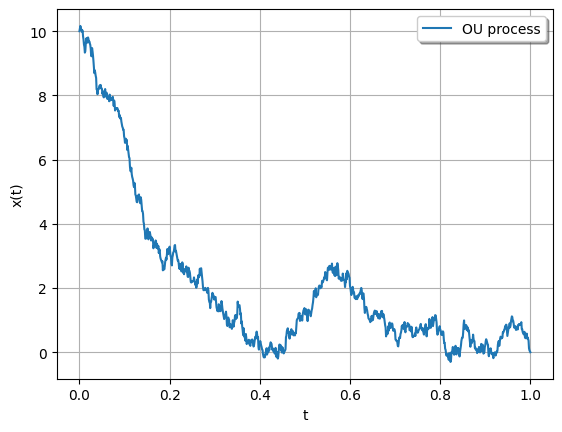

In [ ]:
T = 1
Nx = 1
Nt = 1000

init_state = 10 * np.ones(Nx)

theta = 5
mu = 0
sigma = 3.5
params = [theta, mu, sigma]

OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)
t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'OU process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

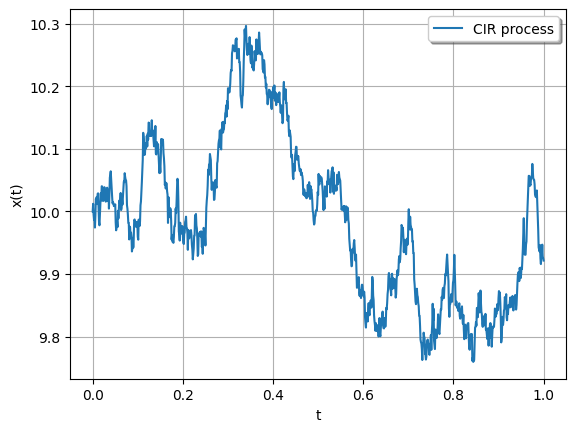

In [ ]:
theta1 = 2
theta2 = 0.2
theta3 = 0.15
params = [theta1, theta2, theta3]

CIRProcess = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'CIR process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

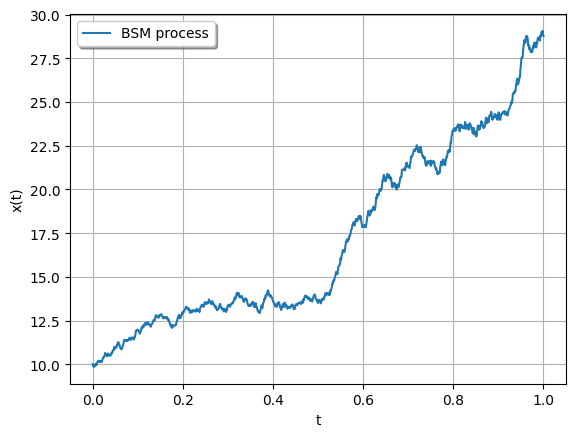

In [ ]:
theta1 = 1.0
theta2 = 0.2
params = [theta1, theta2]

BSMProcess = BlackScholesMertonProcess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'BSM process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Exercise 2. Compute a confidence interval of the CIR process from the previous task. Plot the paths and a confidence interval.

Пример 2. Вычислите доверительный интервал для процесса CIR из предыдущего примера. Постройте графики траекторий и доверительный интервал.

In [ ]:
def zeta(sigma, theta, t, s):
    return sigma**2 / (4 * theta) * (1 - np.exp(-theta * (t - s)))

def CIRbounds(alpha_interval, params, t, s, xs):
    theta1, theta2, theta3 = params[0], params[1], params[2]
    theta = theta2
    beta = theta1 / theta2
    sigma = theta3

    k = 4  / sigma**2 * theta * beta
    lambd = 4 * theta / sigma**2  * np.exp(-theta * (t - s)) / (1 - np.exp(-theta * (t - s))) * xs
    ksi = norm.ppf(1 - alpha_interval / 2)

    b1 = zeta(sigma, theta, t, s) * (k + lambd - ksi * np.sqrt(2 * (k + 2 * lambd)))
    b2 = zeta(sigma, theta, t, s) * (k + lambd + ksi * np.sqrt(2 * (k + 2 * lambd)))
    return [b1, b2]


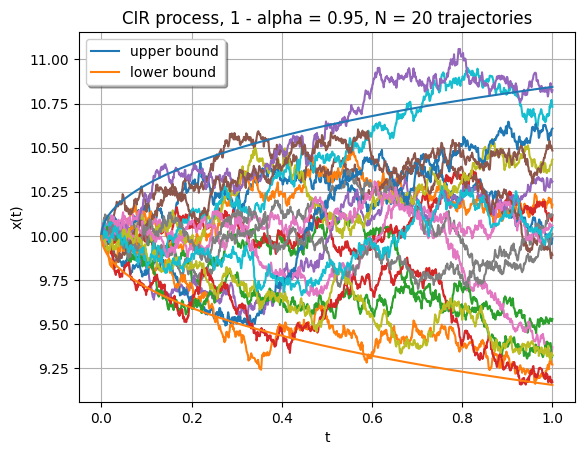

In [ ]:
theta1 = 2
theta2 = 0.2
theta3 = 0.15
params = [theta1, theta2, theta3]

Nx = 20

x0 = 10
init_state = x0 * np.ones(Nx)
alpha_interval = 0.05

CIRProcess = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRProcess.EulerSolution()
for k in range(0, Nx):
    plt.plot(t_data, x_data[:,k])

low_bound_data = np.zeros_like(t_data)
up_bound_data = np.zeros_like(t_data)

for i in range(1, len(t_data)):
    bounds = CIRbounds(alpha_interval, params, t_data[i], 0, x0)
    low_bound_data[i] = bounds[0]
    up_bound_data[i] = bounds[1]
low_bound_data[0] = x0
up_bound_data[0] = x0
plt.plot(t_data, up_bound_data, label = f"upper bound")
plt.plot(t_data, low_bound_data, label = f"lower bound")

plt.title(f"CIR process, 1 - alpha = {1-alpha_interval}, N = {Nx} trajectories")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Exercise 3. For the Ornstein-Uhlenbeck process
$$
dX_t = \theta(\mu - X_t)dt + \sigma dW_t, \quad \theta = 1, \quad \mu = 1.2, \quad \sigma = 0.3
$$
generate three paths: $X_0 = 0.0, 2.0, \mathcal{N}\left(\mu, \frac{\sigma^2}{2\theta}\right)$ and plot in graph.


Пример 3. Для процесса Орштейна-Улумбека
$$
dX_t = \theta(\mu - X_t)dt + \sigma dW_t, \quad \theta = 1, \quad \mu = 1.2, \quad \sigma = 0.3
$$
сгенерируйте три траектории: $X_0 = 0.0, 2.0, \mathcal{N}\left(\mu, \frac{\sigma^2}{2\theta}\right)$ и постройте их на одном графике.


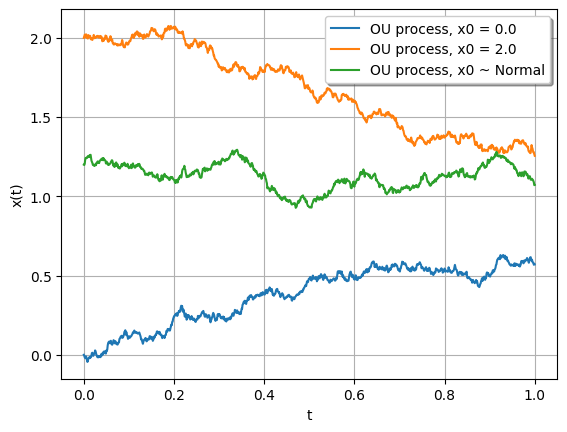

In [ ]:
T = 1
Nx = 1
Nt = 1000

theta = 1
mu = 1.2
sigma = 0.3
params = [theta, mu, sigma]

x0 = 0.0
init_state = x0 * np.ones(Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 = {x0}')

x0 = 2.0
init_state = x0 * np.ones(Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 = {x0}')


init_state = np.random.normal(mu, sigma**2/(2 * theta), size = Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 ~ Normal')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Define a path with the stationary distribution from the graph and prove mathematically.

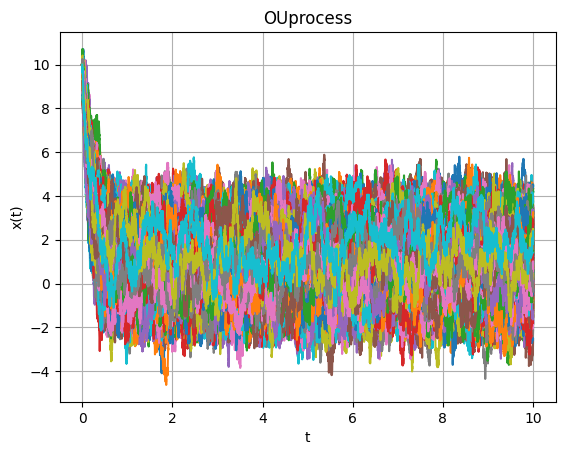

выборочные среднее и дисперсия: 1.044844210476092 1.3268850294856092
95% доверительный интервал: 0.9734484015705833 1.1162400193816007


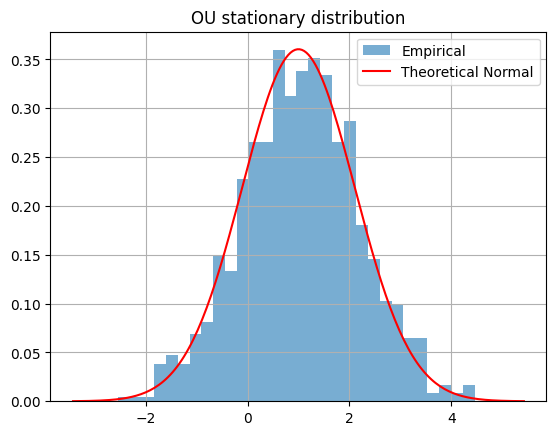

In [ ]:
T = 10
Nx = 1000
Nt = 10000

init_state = 10 * np.ones(Nx)

theta = 5
mu = 1
sigma = 3.5
params = [theta, mu, sigma]

OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)
t_data, x_data = OUProcess.EulerSolution()
for k in range(0, Nx):
    plt.plot(t_data, x_data[:,k])

plt.title("OUprocess")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

m=x_data[-1,:].mean()
v=x_data[-1,:].var()
s=x_data[-1,:].std()
print("выборочные среднее и дисперсия:",m, v)


SE = s / np.sqrt(Nx)
lower = m - 1.96 * SE
upper = m + 1.96 * SE
print("95% доверительный интервал:", lower, upper)

#аналитически
mean = mu
var = sigma**2 / (2*theta)
std = np.sqrt(var)

x_vals = np.linspace(mean - 4*std, mean + 4*std, 200)
pdf = (1/(std*np.sqrt(2*np.pi))) * np.exp(-(x_vals - mean)**2 / (2*std**2))
plt.hist(x_data[-1, :], bins=30, density=True, alpha=0.6, label="Empirical")

plt.plot(x_vals, pdf, 'r', label="Theoretical Normal")

plt.legend()
plt.title("OU stationary distribution")
plt.grid(True)
plt.show()

Exercise 2.  Design a process that stays in the interval $[0, 1]$ and mean-reverts around $1/2$, generate paths for different $\theta$ and plot their in graph. Prove your solution.


Hint
$$
\mu(x) = \theta (1/2 - x), \quad \sigma(x) = \sigma \cdot x (1-x).
$$

That is
$$
dx = \theta (1/2 - x )dt + \sigma \cdot x (1-x) dW.
$$
Note: diffusion goes to zero at boundaries $\sigma(0) = \sigma(1) = 0$ and
mean-reverts  $⇒$ always stay in $[0, 1]$.

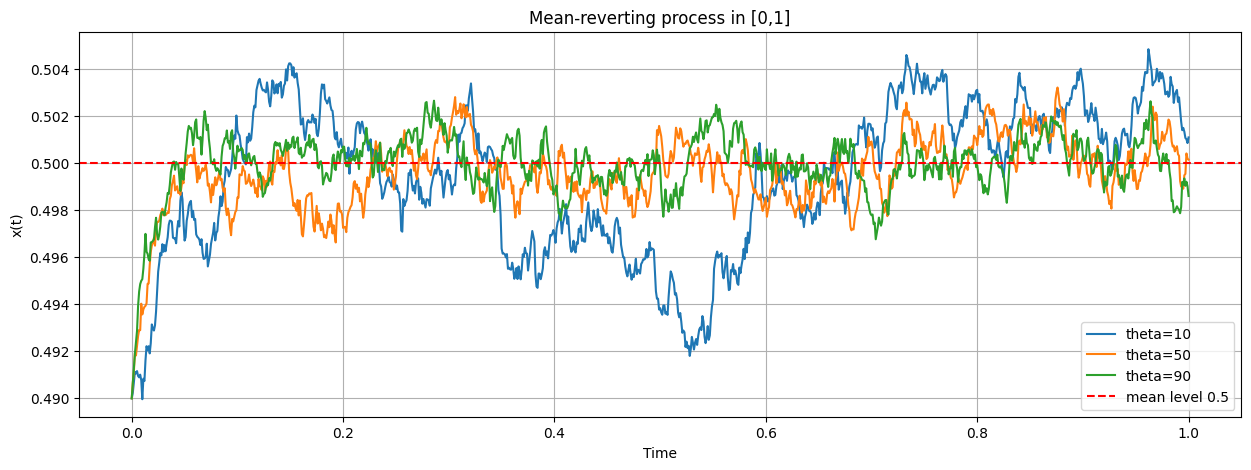

In [ ]:
def DesignProcess():
    T = 1.0
    Nt = 1000
    sigma = 0.05
    dt = T / Nt
    t = np.linspace(0, T, Nt + 1)
    x0 = 0.49

    plt.figure(figsize=(15, 5))

    for theta in [10, 50, 90]:
        x_data = np.zeros(Nt + 1)
        x_data[0] = x0

        for i in range(Nt):
            x_prev = x_data[i]
            drift = theta * (0.5 - x_prev) * dt
            diffusion = sigma * x_prev * (1 - x_prev) * np.sqrt(dt) * np.random.normal()
            x_new = x_prev + drift + diffusion
            x_data[i + 1] = np.clip(x_new, 0, 1)

        plt.plot(t, x_data, label=f'theta={theta}')

    plt.axhline(y=0.5, color='r', linestyle='--', label='mean level 0.5')
    plt.xlabel('Time')
    plt.ylabel('x(t)')
    plt.title('Mean-reverting process in [0,1]')
    plt.legend()
    plt.grid(True)
    plt.show()

DesignProcess()

Exercise 3. Sove Exercise 2 for common case: interval $[a, b]$ and mean-reverts around  $c$, where $c \sim U(a,b)$.

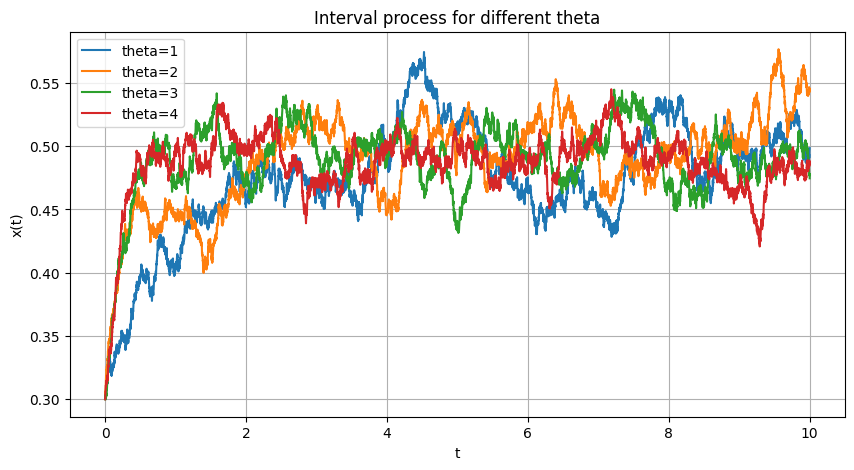

In [ ]:
def simulate_interval_process(T, Nt, theta, sigma, a, b, c, x0):
    dt = T / Nt
    t = np.linspace(0, T, Nt + 1)
    x = np.zeros(Nt + 1)
    x[0] = x0

    for i in range(Nt):
        x_prev = x[i]
        drift = theta * (c - x_prev) * dt
        diffusion = sigma * (x_prev - a) * (b - x_prev) * np.sqrt(dt) * np.random.normal()
        x_new = x_prev + drift + diffusion
        x[i + 1] = np.clip(x_new, a, b)

    return t, x
plt.figure(figsize=(10,5))

for theta in range(1, 5):
    t, x_data = simulate_interval_process(10, 10000, theta, 0.2, 0, 1, 0.5, 0.3)
    plt.plot(t, x_data, label=f'theta={theta}')

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Interval process for different theta")
plt.legend()
plt.grid(True)
plt.show()

Exercise 4. Using the class template from Task 1, create classes and plot graphs for the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

Provide examples for illustration the results on graphs.





In [ ]:
class ModifiedCIRProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [ ]:
class CKLSProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma, alpha]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * x ** self.params[3]

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [ ]:
class AitSahaliaProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x ** 2)
        self.sigmaxt = lambda x: self.params[2]

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1] ** 0.5)

In [ ]:
class JacobiProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * (1 - x) * (1 + x)

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [ ]:
class AhnGaoProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [ ]:
class RadialOUProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, sigma]
        self.bxt = lambda x: -self.params[0] * x
        self.sigmaxt = lambda x: self.params[1]

    def sampler_init_state(self):
        return np.zeros(self.Nx)  # Starting at the origin

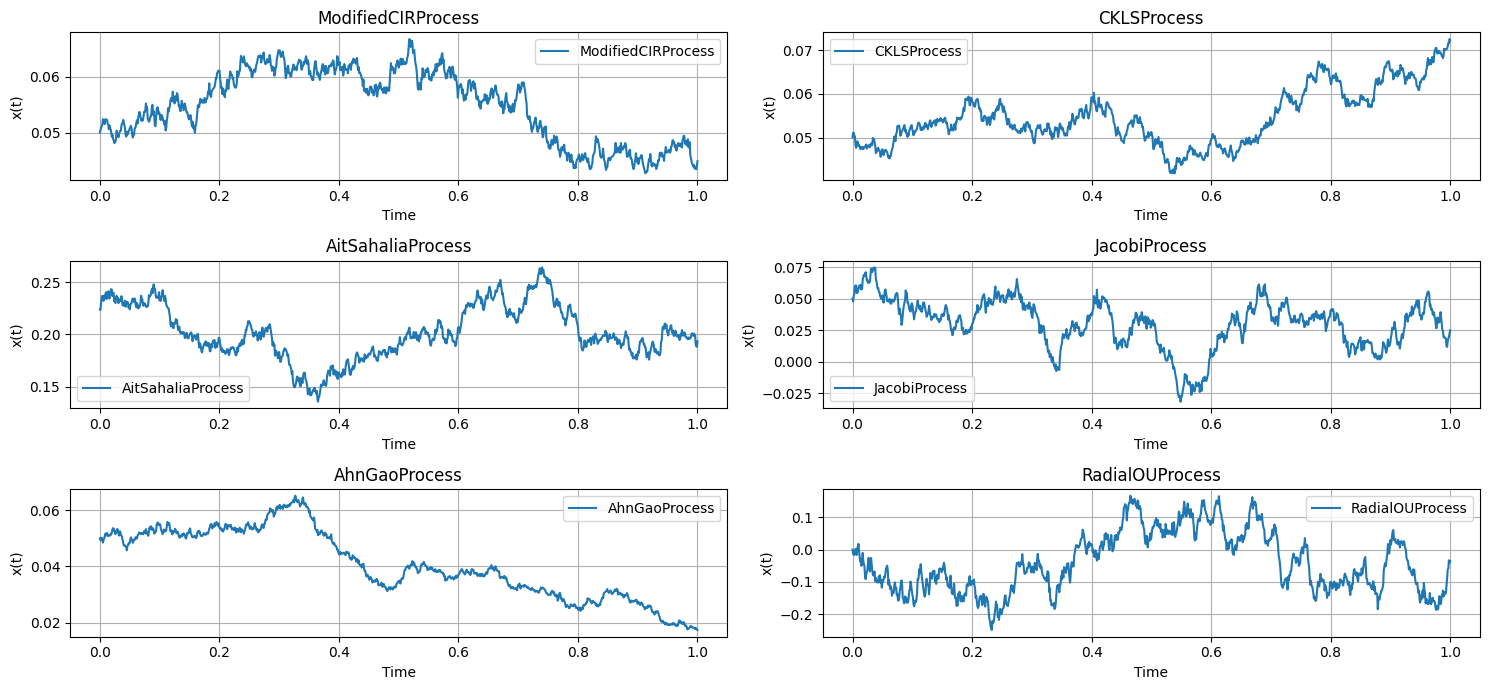

In [ ]:
# Common parameters for the models
T = 1.0
Nx = 1
Nt = 1000

# Parameters for each model
params_cir = [0.1, 0.05, 0.1]  # Modified CIR
params_ckls = [0.1, 0.05, 0.1, 0.5]  # CKLS
params_ait = [0.1, 0.05, 0.1]  # Ait-Sahalia
params_jacobi = [0.1, 0.05, 0.1]  # Jacobi
params_ahn = [0.1, 0.05, 0.1]  # Ahn and Gao
params_radial_ou = [15, 0.5]  # Radial OU

# Create instances of each process
processes = [
    ModifiedCIRProcess(params_cir, T, Nx, Nt),
    CKLSProcess(params_ckls, T, Nx, Nt),
    AitSahaliaProcess(params_ait, T, Nx, Nt),
    JacobiProcess(params_jacobi, T, Nx, Nt),
    AhnGaoProcess(params_ahn, T, Nx, Nt),
    RadialOUProcess(params_radial_ou, T, Nx, Nt)
]

# Plotting each process
plt.figure(figsize=(15, 7))

for i, process in enumerate(processes):
    t_data, x_data = process.EulerSolution()
    plt.subplot(3, 2, i + 1)
    plt.plot(t_data, x_data, label=process.__class__.__name__)
    plt.title(process.__class__.__name__)
    plt.xlabel('Time')
    plt.ylabel('x(t)')
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

Exercise 5.

Let $$X(t)=e^{-\kappa t} X_0 + \theta (1-e^{-\kappa t}) + \sigma e^{-\kappa t} \int_0^t e^{\kappa s}\sqrt{X(t)}dW(s)$$ be extract solution for CIR model.


 Expand the functionality of the class CoxIngersollRossProcess(StochasticProcess) and compute the first and second moments of the extract solution $\mathbb{E}\{X^n(t)\}$ using the general formula [Jafari, 2017]
$$
\mathbb{E}\{X^n(t)\} = \sum_{j=0}^{[n/2]}A^{n-2j}(t)B^{2j}(t)
\left(\frac{1}{2\kappa}(e^{2\kappa t} - 1)\right)^{2j}, \quad \forall n \in \mathbb{N},
$$
where $A(t)=e^{-\kappa t X_0} + \theta(1-e^{-\kappa t})$,
$B(t)=\sigma e^{-\kappa t}$, $[n/2]$ denotes the greatest integer less than or equal to $\frac{n}{2}$ and $\kappa=1$, $\theta =0.45$, $\sigma=1$.



Jafari M.A. [The Moments for Solution of the Cox-Ingersoll-Ross Interest Rate Model](https://www.sciepub.com/portal/downloads?doi=10.12691/jfe-5-1-4&filename=jfe-5-1-4.pdf) / M.A. Jafari, S. Abbasian // Journal of Finance
and Economics. – 2017. – Vol. 5, № 1. – P. 34—37

In [ ]:
import sympy as sp
from sympy import latex
from IPython.display import display, Math

# Определяем символы
X0, theta, kappa, sigma, t, n = sp.symbols('X0 theta kappa sigma t n')

# Функции A(t) и B(t)
def A(t):
    return sp.exp(-kappa * t) * X0 + theta * (1 - sp.exp(-kappa * t))

def B(t):
    return sigma * sp.exp(-kappa * t)

# Подставляем A(t) и B(t) без конкретных значений параметров
A_t = A(t)
B_t = B(t)

# Функция для вычисления n-го момента
def expected_moment(n):
    moment = 0
    max_j = n // 2  # [n/2]

    for j in range(max_j + 1):
        # Вычисляем A(t)^(n-2j) и B(t)^(2j)
        A_term = A_t**(n - 2 * j)
        B_term = B_t**(2 * j)

        # Часть с kappa
        kappa_part = (1 / (2 * kappa)) * (sp.exp(2 * kappa * t) - 1)
        kappa_term = kappa_part**(2 * j)

        # Суммируем
        moment += A_term * B_term * kappa_term

    return moment  # Возвращаем без подстановки значения t и вычисления

# Вычисляем первый и второй моменты
first_moment = expected_moment(1)
second_moment = expected_moment(2)

# Выводим общие аналитические результаты
display(Math(r'\mathbb{E}\{X(t)\} = ' + latex(first_moment)))
display(Math(r'\mathbb{E}\{X^2(t)\} = ' + latex(second_moment)))

# Конкретные значения параметров
kappa_val = 1
theta_val = 0.45
sigma_val = 1
t_val = 1  # Значение для t
X0_val = 0  # Значение для X0

# Подставляем значения параметров
first_moment_value = first_moment.subs({kappa: kappa_val, theta: theta_val, sigma: sigma_val, t: t_val, X0: X0_val}).evalf()
second_moment_value = second_moment.subs({kappa: kappa_val, theta: theta_val, sigma: sigma_val, t: t_val, X0: X0_val}).evalf()

# Выводим конкретные значения
print(f"E{{X(t)}} = {first_moment_value}")
print(f"E{{X^2(t)}} = {second_moment_value}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280


In [ ]:
class CoxIngersollRossProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, kappa, sigma]
        self.bxt = lambda x: self.params[1] * (self.params[0] - x)  # kappa * (theta - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))  # sigma * sqrt(X)

    def sampler_init_state(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def expected_moment(self, n, t):
        # Определяем A(t) и B(t) с учетом параметров
        X0 = self.init_state if self.init_state is not None else self.params[0] / self.params[1]
        A_t = sp.exp(-self.params[1] * t) * X0 + self.params[0] * (1 - sp.exp(-self.params[1] * t))
        B_t = self.params[2] * sp.exp(-self.params[1] * t)

        moment = 0
        max_j = n // 2  # [n/2]

        for j in range(max_j + 1):
            A_term = A_t**(n - 2 * j)
            B_term = B_t**(2 * j)
            kappa_part = (1 / (2 * self.params[1])) * (sp.exp(2 * self.params[1] * t) - 1)
            kappa_term = kappa_part**(2 * j)
            moment += A_term * B_term * kappa_term

        return moment

# Пример использования класса
params = [0.45, 1, 1]  # [theta, kappa, sigma]
T = 1
Nx = 1
Nt = 100
init_state = 0

cir_process = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)

# Вычисление первого и второго моментов в t=1
t_val = 1
first_moment = cir_process.expected_moment(1, t_val)
second_moment = cir_process.expected_moment(2, t_val)

# Выводим результаты
print(f"E{{X(t)}} = {first_moment.evalf()}")
print(f"E{{X^2(t)}} = {second_moment.evalf()}")

print(f"E{{X(t)}} = {first_moment_value}")
print(f"E{{X^2(t)}} = {second_moment_value}")

E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280
E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280


Exercise 5. Let assume  the CoxIngersoll-Ross model
$$
dX_t = (6 - 2X_t)dt + θ \sqrt{X_t}dW_t,
$$
where $θ = θ_1 = 1$ for $t < τ_0 = 0.6$ and $θ = θ_2$ for $t ≥ τ_0$ and $t ∈ (0, 1)$.

Simulate two paths $X_1$ and $X_2$ of the CIR process, one in $[0, τ_0]$ and the other in $[τ_0, 1]$, under the condition $X_2(τ_0) = X_1(τ_0)$, and we collate the two into one single trajectory.

Plot the path and add change point into graph (vetrical line).

Estimate $\hat{τ}$  and the two values of the volatility $\hat{θ}_1$ and $\hat{θ}_2$.

(Iuacus, 2008, p.208)

In [ ]:
# your code

Task 7. Suppose we have a standard (zero-mean) Ornstein-Uhlenbeck process defined by
$$
dX_t = -\theta X_t dt + \sigma dW_t, \quad X_0 = x_0,
$$
where $\sigma$ is interpreted as the volatility, and $\theta$ is the speed of reversion.

Define a half-life at time $s$ as the time $h$ such that $𝔼(x_h|x_s)=\frac{1}{2}x_s$. That is, how long until half the deviation from the mean is, in expectation, lost.

This is easy to compute because
\begin{align}
  \frac{1}{2}x_s & =  𝔼(x_h|x_s) \\
                 & = x_s\exp(-\theta h)
\end{align}
and we can cancel the $x_s$ terms to give
\begin{align}
  \frac{1}{2} = \exp(-\theta h)
\end{align}
which rearranges to
\begin{align}
  h = \frac{\ln(2)}{\theta}
\end{align}
The cancellation of $x_s$ means that a half-life does not depend on either $s$ or $x_s$ and so we are entitled to call it "the" half-life of the process.

As one can see, the half-life is a constant for an Ornstein-Uhlenbeck process.



In [ ]:
# ваш код

Пример. Смоделируйте составную траекторию с использованием процесса Cox-Ingersoll-Ross (CIR)
$$
dX_t = (6 - 2X_t)dt + \theta \sqrt{X_t}dW_t,  X(0)=1,
$$
где

$\theta = \theta_1 = 1$ для $t < \tau_0 = 0.6$ и

$\theta = \theta_2$ и $t \geq \tau_0$, $t \in (0, 1)$.

Постройте график смоделированной траектории, а также график статистики $|\hat{D}_k|$, укажите точку смены тенденции $k_0$ на графике траектории и сравните полученное значание с $\tau_0$.

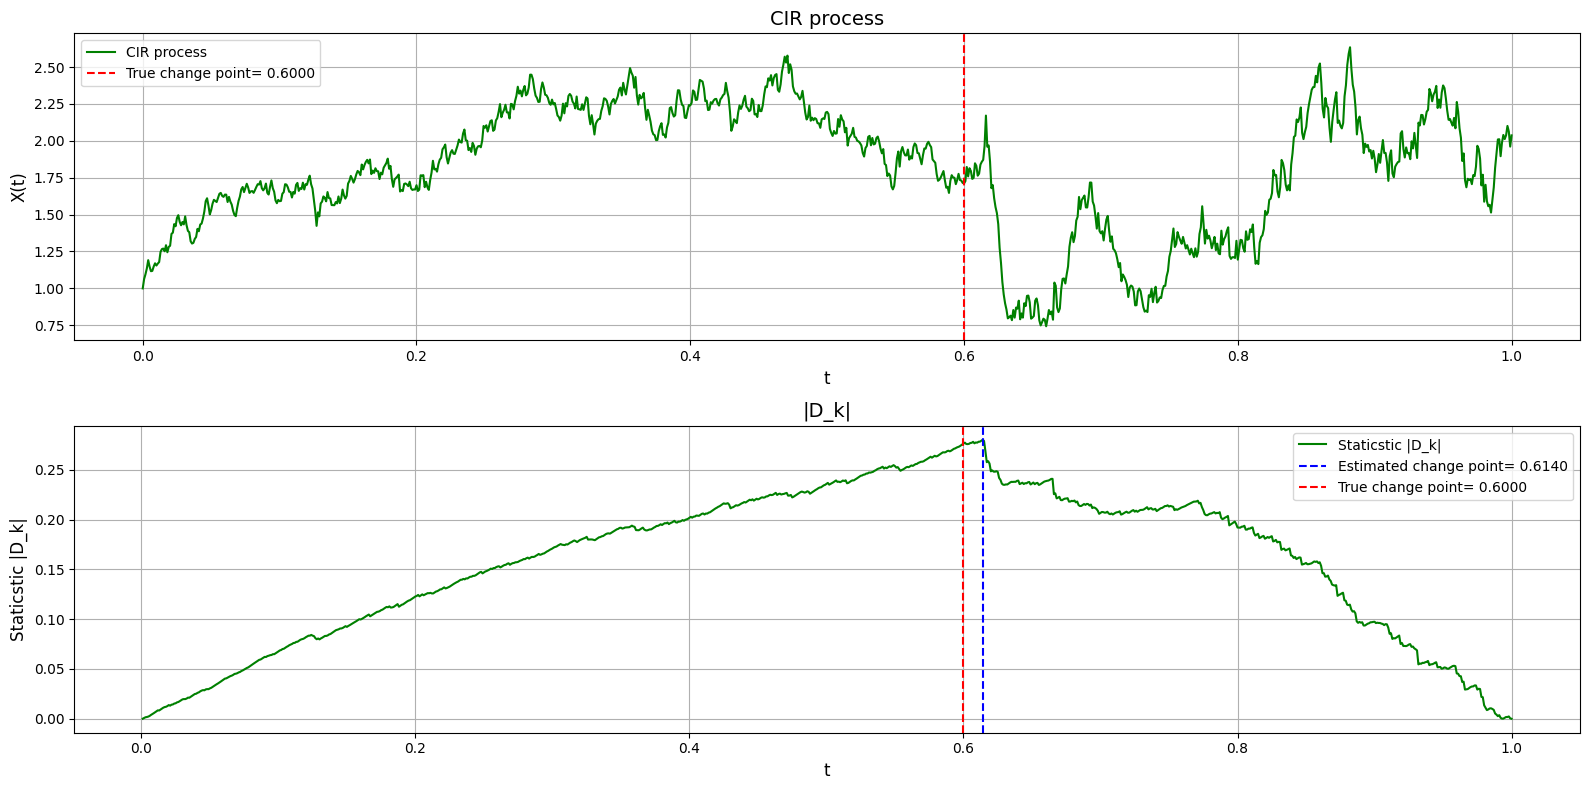

Истинный: t₀ = 0.6
Оценённый: y₀ = 0.6140


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class CIRProcessSimulation:
    def __init__(self, n=1000, T=1.0, tau0=0.6, theta1=1.0, theta2=2.0, X0=1.0):
        self.n = n
        self.T = T
        self.tau0 = tau0
        self.theta1 = theta1
        self.theta2 = theta2
        self.X0 = X0
        self.Δt = self.T / self.n
        self.t = np.linspace(0, self.T, self.n + 1)
        self.X = np.zeros(self.n + 1)
        self.X[0] = self.X0
        self.D_k = None

    def simulate(self):
        ΔW = np.sqrt(self.Δt) * np.random.randn(self.n)
        for i in range(self.n):
            theta = self.theta1 if self.t[i] < self.tau0 else self.theta2
            sqrt_Xi = np.sqrt(max(self.X[i], 0))
            self.X[i+1] = self.X[i] + (6 - 2 * self.X[i]) * self.Δt + theta * sqrt_Xi * ΔW[i]
            self.X[i+1] = max(self.X[i+1], 0)

    def estimate_change_point(self):
        Z = ((self.X[1:] - self.X[:-1]) - (6 - 2 * self.X[:-1]) * self.Δt) / np.sqrt(self.Δt)
        Z_squared = Z**2
        S_k = np.cumsum(Z_squared)
        S_n = S_k[-1]
        k_values = np.arange(1, self.n + 1)
        self.D_k = (S_k / S_n) - (k_values / self.n)
        k0 = np.argmax(np.abs(self.D_k))
        t0_estimate = self.t[k0 + 1]
        return t0_estimate

    def plot_results(self, t0_estimate):
        fig, axs = plt.subplots(2, 1, figsize=(16, 8))

        # Plot process
        axs[0].plot(self.t, self.X, color='green', label='CIR process')
        axs[0].axvline(x=self.tau0, color='red', linestyle='--', label=f'True change point= {tau0:.4f}')
        axs[0].set_xlabel('t', fontsize=12)
        axs[0].set_ylabel('X(t)', fontsize=12)
        axs[0].set_title('CIR process', fontsize=14)
        axs[0].legend()
        axs[0].grid(True)

        # Plot estimation
        axs[1].plot(self.t[1:], np.abs(self.D_k), color='green', label='Staticstic |D_k|')
        axs[1].axvline(x=t0_estimate, color='blue', linestyle='--', label=f'Estimated change point= {t0_estimate:.4f}')
        axs[1].axvline(x=self.tau0, color='red', linestyle='--', label=f'True change point= {tau0:.4f}')
        axs[1].set_xlabel('t', fontsize=12)
        axs[1].set_ylabel('Staticstic |D_k|', fontsize=12)
        axs[1].set_title('|D_k|', fontsize=14)
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout()
        plt.show()

tau0 = 0.6
simulation = CIRProcessSimulation()
simulation.simulate()
t0_estimate = simulation.estimate_change_point()

simulation.plot_results(t0_estimate)

print(f"Истинный: t₀ = {simulation.tau0}")
print(f"Оценённый: y₀ = {t0_estimate:.4f}")

# Задачи

Задача 1. Верификация моментов процесса CIR (Раздел 2.3, 8.1)

Для модели CIR существуют аналитические формулы для расчета моментов любого порядка.
1. На основе формулы (Jafari, 2017) вычислите теоретические значения первого и второго моментов $\mathbb E\{X(t)\}$ и $\mathbb E\{X^2(t)\}$ для параметров $κ$, $θ$, $σ$ (задать самостоятельно).

2. Сгенерируйте $M=1000$ траекторий и вычислите выборочное среднее и дисперсию в момент времени $T$ и сравните их с теоретическими значениями, рассчитанными по формуле (Jafari, 2017).

3. Сделайте выводы.

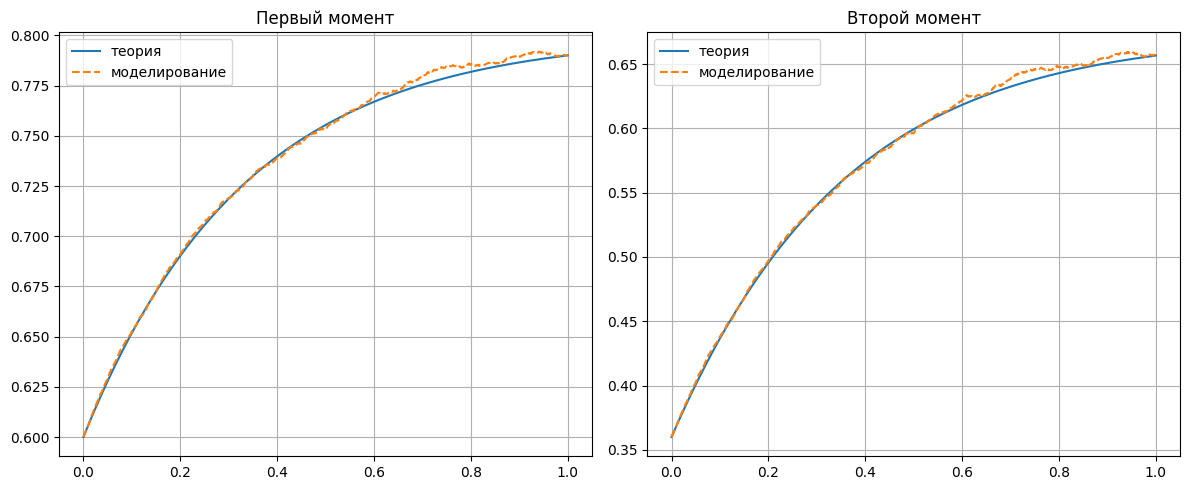

E[X(T)] теория: 0.7900425863264272
E[X(T)] моделирование: 0.7901679112177938
E[X^2(T)] теория: 0.656629524533608
E[X^2(T)] моделирование: 0.6571108286030224


In [5]:
kappa = 3.0
theta = 0.8
sigma = 0.5
x0 = 0.6

T = 1.0
Nt = 1000
Nx = 5000

dt = T / Nt
t = np.linspace(0, T, Nt + 1)

# теоретический первый момент
m1 = theta + (x0 - theta) * np.exp(-kappa * t)

# теоретическая дисперсия
var = (x0 * sigma**2 / kappa) * (np.exp(-kappa * t) - np.exp(-2 * kappa * t)) \
    + (theta * sigma**2 / (2 * kappa)) * (1 - np.exp(-kappa * t))**2

# теоретический второй момент
m2 = var + m1**2

# моделирование траекторий
X = np.zeros((Nt + 1, Nx))
X[0] = x0

for i in range(Nt):
    dW = np.sqrt(dt) * np.random.randn(Nx)
    X_prev = np.maximum(X[i], 0)
    X[i + 1] = X_prev + kappa * (theta - X_prev) * dt + sigma * np.sqrt(X_prev) * dW
    X[i + 1] = np.maximum(X[i + 1], 0)

# эмпирические моменты
m1_emp = np.mean(X, axis=1)
m2_emp = np.mean(X**2, axis=1)

# графики
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, m1, label='теория')
plt.plot(t, m1_emp, '--', label='моделирование')
plt.title('Первый момент')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t, m2, label='теория')
plt.plot(t, m2_emp, '--', label='моделирование')
plt.title('Второй момент')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

print("E[X(T)] теория:", m1[-1])
print("E[X(T)] моделирование:", m1_emp[-1])
print("E[X^2(T)] теория:", m2[-1])
print("E[X^2(T)] моделирование:", m2_emp[-1])

Задача 2. Свойства модели Блэка-Шоулза-Мертона (Раздел 2.2, 8.4)

Условная плотность процесса BSM является логнормальной.
1. Задайте параметры $θ_1=16\%$ (процентная ставка) и $θ_2=30\%$  (волатильность) и смоделируйте процесс геометрического броуновского движения.
2. Постройте гистограмму значений $\log(X_T​ /X_0)$ и стаститически проверьте её на соответствие нормальному распределению с параметрами
$μ=(θ_1 −θ_2^2/2)T$ и $σ^2 =θ_2^2​ T$. Приведите значение статистики критерия, p-value и пороговое значение.
3. Сделайте выводы.

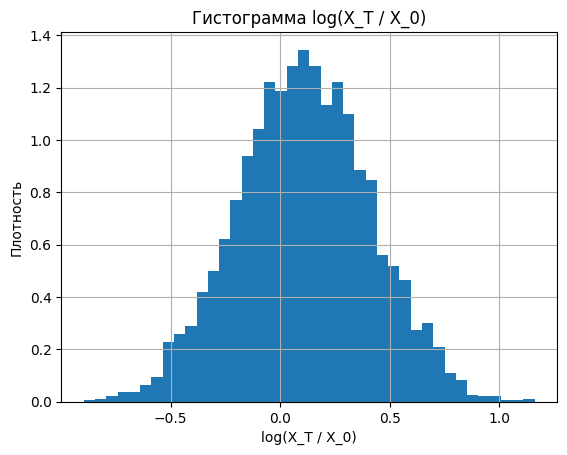

Статистика критерия: 0.012167014892290218
p-value: 0.44625523779171195
Пороговое значение: 0.019233304448274095
Нет оснований отвергнуть H0: распределение согласуется с нормальным.


In [4]:
from scipy import stats

# параметры
theta1 = 0.16
theta2 = 0.30
T = 1
X0 = 100
N = 5000

# моделируем X_T в модели BSM
Z = np.random.randn(N)
XT = X0 * np.exp((theta1 - theta2**2 / 2) * T + theta2 * np.sqrt(T) * Z)

# считаем log(X_T / X_0)
Y = np.log(XT / X0)

# теоретические параметры нормального распределения
mu = (theta1 - theta2**2 / 2) * T
sigma = theta2 * np.sqrt(T)


plt.hist(Y, bins=40, density=True)
plt.title('Гистограмма log(X_T / X_0)')
plt.xlabel('log(X_T / X_0)')
plt.ylabel('Плотность')
plt.grid(True)
plt.show()

# критерий Колмогорова-Смирнова
statistic, p_value = stats.kstest(Y, 'norm', args=(mu, sigma))

# пороговое значение при alpha = 0.05
alpha = 0.05
critical_value = 1.36 / np.sqrt(N)

print("Статистика критерия:", statistic)
print("p-value:", p_value)
print("Пороговое значение:", critical_value)

if statistic < critical_value:
    print("Нет оснований отвергнуть H0: распределение согласуется с нормальным.")
else:
    print("H0 отвергается: распределение не согласуется с нормальным.")

Задача 3. Модель стохастической волатильности (BSM + CIR)

1. C помощью модели Cox-Ingersoll-Ross (CIR) сгенерируйте траекторию волатильности $\sigma(t)$ с параметрами, обеспечивающими положительность процесса.
2. В класс BlackScholesMertonProcess передайте значение $\sqrt{\sigma(t)}$  из пункта 1.
3. Визуализируйте на двух подобъектах (subplots): верхний график — траектория волатильности (CIR), нижний — цена актива (модифицированный BSM).
4. Сохраните результаты моделирования в файл (*.csv).
5. Сделайте выводы.



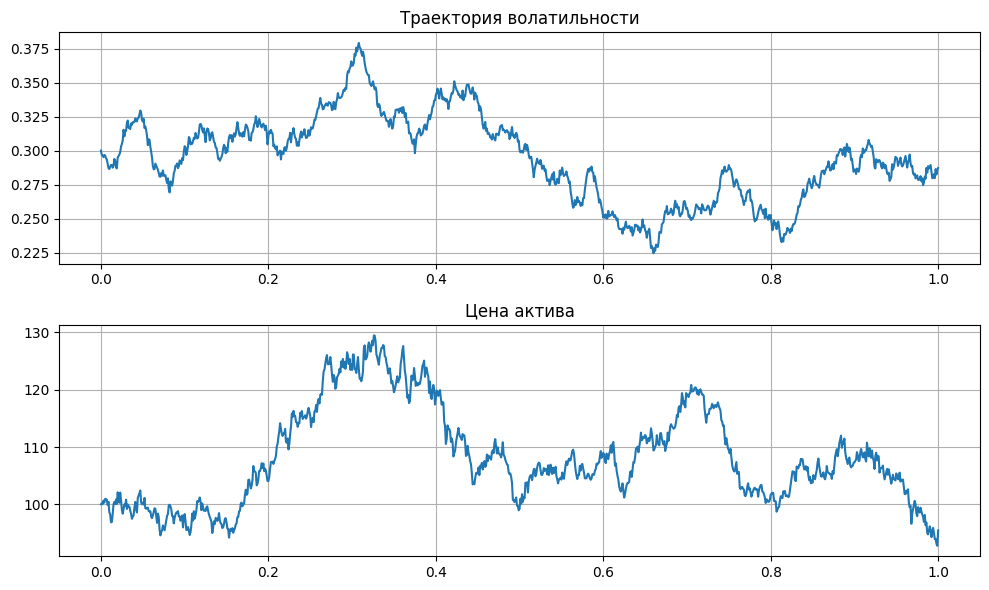

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# параметры CIR для дисперсии
kappa = 3.0
theta = 0.09
eta = 0.2
v0 = 0.09

# параметры цены актива
r = 0.16
S0 = 100

T = 1.0
N = 1000
dt = T / N
t = np.linspace(0, T, N + 1)

# 1. моделируем CIR-процесс для дисперсии V(t)
V = np.zeros(N + 1)
V[0] = v0

for i in range(N):
    dW = np.sqrt(dt) * np.random.randn()
    V_prev = max(V[i], 0)
    V[i + 1] = V_prev + kappa * (theta - V_prev) * dt + eta * np.sqrt(V_prev) * dW
    V[i + 1] = max(V[i + 1], 0)

# волатильность sigma(t) = sqrt(V(t))
sigma_t = np.sqrt(V)

# 2. моделируем цену актива
S = np.zeros(N + 1)
S[0] = S0

for i in range(N):
    dW = np.sqrt(dt) * np.random.randn()
    S[i + 1] = S[i] + r * S[i] * dt + sigma_t[i] * S[i] * dW

# 3. графики
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, sigma_t)
plt.title('Траектория волатильности')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, S)
plt.title('Цена актива')
plt.grid()

plt.tight_layout()
plt.show()

# 4. сохранение в csv
data = pd.DataFrame({
    't': t,
    'sigma_t': sigma_t,
    'S_t': S
})

data.to_csv('stochastic_volatility_model.csv', index=False)

--------------------------------------------------------------------------------
Задача 4. Смена режима для траектории (Regime Switching)

1. Сгенерируйте траекторию процесса Ornstein-Uhlenbeck (OU) на интервале $t∈[0,0.5]$ с параметрами, обеспечивающими возврат к среднему $\mu=1.2$.
2. В момент времени $\tau_0=0.5$ (точка смены режима) переключите динамику системы на модель Ait-Sahalia или Black-Scholes-Merton, используя конечное значение OU-процесса как начальное состояние для следующего этапа $t\in [0.5; 1.0]$.
3. Соедините две траектории в одну и постройте график, отметив вертикальной линией момент смены режима.
4. Стастический оцените точку смены тенденции и сравните ее c $\tau_0$. Постройте график статистики и нанесите две вертикальные линии для $\tau_0$ и ее оценки.
5. Сохраните результаты моделирования в файл (*.csv).
6. Сделайте выводы. Объясните, как меняются свойства траектории.

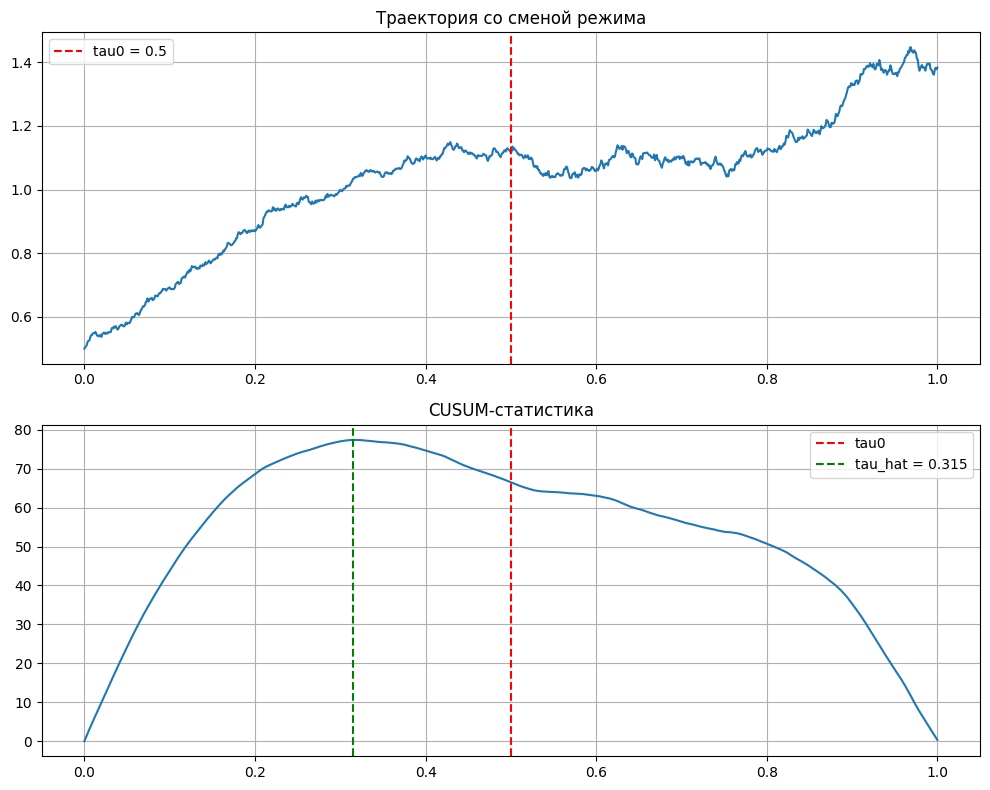

Истинная точка смены tau0 = 0.5
Оценка точки смены tau_hat = 0.315


In [7]:
np.random.seed(42)

T = 1.0
N = 1000
dt = T / N
t = np.linspace(0, T, N + 1)

tau0 = 0.5
k0 = int(tau0 / dt)


# OU на [0, 0.5]
# dX = theta*(mu - X)dt + sigma dW

theta = 4.0
mu = 1.2
sigma_ou = 0.15
x0 = 0.5

X1 = np.zeros(k0 + 1)
X1[0] = x0

for i in range(k0):
    dW = np.sqrt(dt) * np.random.randn()
    X1[i + 1] = X1[i] + theta * (mu - X1[i]) * dt + sigma_ou * dW


#  BSM на [0.5, 1.0]
# dX = r X dt + sigma X dW

r = 0.25
sigma_bsm = 0.2

X2 = np.zeros(N - k0 + 1)
X2[0] = X1[-1]

for i in range(N - k0):
    dW = np.sqrt(dt) * np.random.randn()
    X2[i + 1] = X2[i] + r * X2[i] * dt + sigma_bsm * X2[i] * dW

# объединяем траектории

X = np.concatenate([X1, X2[1:]])

# оценка точки смены режима (CUSUM)

mean_X = np.mean(X)
cusum = np.zeros(len(X))

for k in range(1, len(X)):
    cusum[k] = np.abs(np.sum(X[:k] - mean_X))

k_hat = np.argmax(cusum)
tau_hat = t[k_hat]


plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(t, X)
plt.axvline(tau0, color='r', linestyle='--', label='tau0 = 0.5')
plt.title('Траектория со сменой режима')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, cusum)
plt.axvline(tau0, color='r', linestyle='--', label='tau0')
plt.axvline(tau_hat, color='g', linestyle='--', label=f'tau_hat = {tau_hat:.3f}')
plt.title('CUSUM-статистика')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

print("Истинная точка смены tau0 =", tau0)
print("Оценка точки смены tau_hat =", tau_hat)


data = pd.DataFrame({
    't': t,
    'X_t': X,
    'CUSUM': cusum
})

data.to_csv('regime_switching.csv', index=False)

Задача 5. Сравнение моделей с возвратом к среднему и их калибровка

1. Рассмотрите следующие модели

Ornstein–Uhlenbeck (OU):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma dW_t
  $$  

Cox–Ingersoll–Ross (CIR):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma \sqrt{X_t} dW_t
  $$  

Модифицированный CIR (с добавлением квадратичного члена в волатильности):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma X_t^{3/2} dW_t
  $$  
  
Модель Ait–Sahalia с нелинейным дрейфом:  
  $$
  dX_t = (\alpha_{-1}X_t^{-1} + \alpha_0 + \alpha_1 X_t + \alpha_2 X_t^2) dt + \sigma X_t^{\rho} dW_t
  $$  

Диффузия Якоби (ограниченная на интервале):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma \sqrt{X_t(1 - X_t)} dW_t, \quad X_t \in (0,1)
  $$  

Для каждой модели самостоятельно укажите:  
  - область значений процесса;  
  - условия на параметры, обеспечивающие строгую положительность (если требуется);  
  - выражение для стационарной плотности распределения (если она существует).  


2. Сгенерируйте по 500 траекторий для каждой из пяти моделей с использованием следующих зачений параметров:  
  $$
  \kappa = 2.0,\quad \theta = 1.0,\quad X_0 = 1.5,\quad T = 2.0,\quad \Delta t = 0.001
  $$  
  Для волатильности используйте:  
  $$
  \sigma = 0.3 \quad \text{(для моделей, где это подходит)}.
  $$  
  Для модели Ait–Sahalia используйте:  
  $$
  \alpha_{-1}=0.5,\ \alpha_0=0.1,\ \alpha_1=-2,\ \alpha_2=0,\ \rho=1.5.
  $$  

   

3. Для каждой модели оцените:  
  - выборочное среднее и дисперсию в момент $T$;  
  - выборочный коэффициент возврата к среднему (оцените скорость сходимости к $\theta$;  
  - вероятности выхода процессов за заданные пороги $X_t < 0.5$ и $X_t > 2.0$ на промежутке $[0, T]$.  

4. Постройте на одном графике 10 траекторий каждой модели (разными цветами) и отдельно график выборочных средних по времени для всех моделей.  

5. Сделайте выводы.

Результаты в момент T:

OU
  mean(T) = 0.9921094550098687
  var(T)  = 0.021429923020768994
  mean reversion speed = 0.7174749865921034
  P(min X_t < 0.5) = 0.006
  P(max X_t > 2.0) = 0.0

CIR
  mean(T) = 1.0138180794276577
  var(T)  = 0.024861180547583975
  mean reversion speed = 0.6990819005796347
  P(min X_t < 0.5) = 0.0
  P(max X_t > 2.0) = 0.0

Modified CIR
  mean(T) = 1.0108158447742632
  var(T)  = 0.027461604978130966
  mean reversion speed = 0.690316763324967
  P(min X_t < 0.5) = 0.0
  P(max X_t > 2.0) = 0.036

Ait-Sahalia
  mean(T) = 0.5307799396566208
  var(T)  = 0.001669031301774855
  mean reversion speed = 0.03176811410089229
  P(min X_t < 0.5) = 0.902
  P(max X_t > 2.0) = 0.0

Jacobi
  mean(T) = 0.9947760143514022
  var(T)  = 0.00019016059613092572
  mean reversion speed = 1.8225283608916534
  P(min X_t < 0.5) = 0.0
  P(max X_t > 2.0) = 0.0



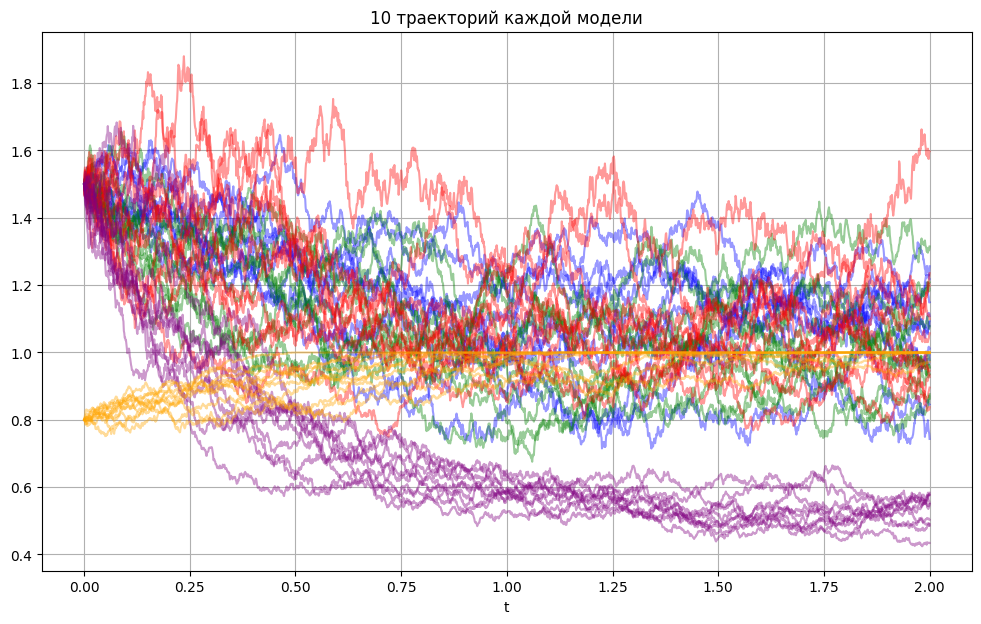

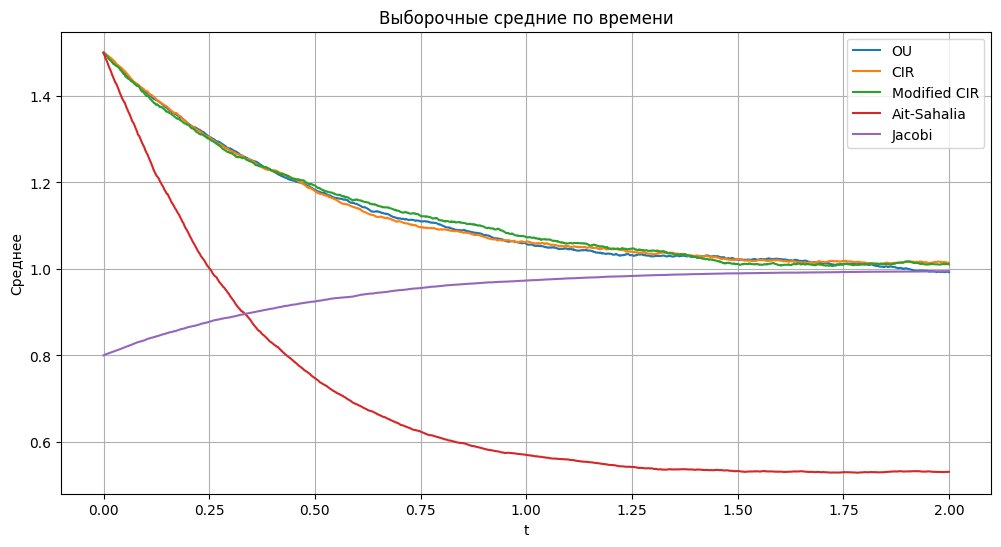

In [10]:
np.random.seed(42)

kappa = 2.0
theta = 1.0
sigma = 0.3
x0 = 1.5

T = 2.0
dt = 0.001
N = int(T / dt)
M = 500
t = np.linspace(0, T, N + 1)

# параметры Ait-Sahalia
a_m1 = 0.5
a0 = 0.1
a1 = -2.0
a2 = 0.0
rho = 1.5

# для Jacobi нужен старт в (0,1)
x0_jacobi = 0.8


def simulate_ou():
    X = np.zeros((N + 1, M))
    X[0] = x0
    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)
        X[i + 1] = X[i] + kappa * (theta - X[i]) * dt + sigma * dW
    return X

def simulate_cir():
    X = np.zeros((N + 1, M))
    X[0] = x0
    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)
        X_prev = np.maximum(X[i], 0)
        X[i + 1] = X_prev + kappa * (theta - X_prev) * dt + sigma * np.sqrt(X_prev) * dW
        X[i + 1] = np.maximum(X[i + 1], 0)
    return X

def simulate_cir_mod():
    X = np.zeros((N + 1, M))
    X[0] = x0
    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)
        X_prev = np.maximum(X[i], 0)
        X[i + 1] = X_prev + kappa * (theta - X_prev) * dt + sigma * (X_prev ** 1.5) * dW
        X[i + 1] = np.maximum(X[i + 1], 0)
    return X

def simulate_ait_sahalia():
    X = np.zeros((N + 1, M))
    X[0] = x0
    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)
        X_prev = np.maximum(X[i], 1e-6)
        drift = a_m1 / X_prev + a0 + a1 * X_prev + a2 * X_prev**2
        diffusion = sigma * (X_prev ** rho)
        X[i + 1] = X_prev + drift * dt + diffusion * dW
        X[i + 1] = np.maximum(X[i + 1], 1e-6)
    return X

def simulate_jacobi():
    X = np.zeros((N + 1, M))
    X[0] = x0_jacobi
    for i in range(N):
        dW = np.sqrt(dt) * np.random.randn(M)
        X_prev = np.clip(X[i], 1e-6, 1 - 1e-6)
        X[i + 1] = X_prev + kappa * (theta - X_prev) * dt + sigma * np.sqrt(X_prev * (1 - X_prev)) * dW
        X[i + 1] = np.clip(X[i + 1], 1e-6, 1 - 1e-6)
    return X


OU = simulate_ou()
CIR = simulate_cir()
CIR_mod = simulate_cir_mod()
AIT = simulate_ait_sahalia()
JAC = simulate_jacobi()

models = {
    'OU': OU,
    'CIR': CIR,
    'Modified CIR': CIR_mod,
    'Ait-Sahalia': AIT,
    'Jacobi': JAC
}


# оценки
print("Результаты в момент T:\n")

for name, X in models.items():
    mean_T = np.mean(X[-1])
    var_T = np.var(X[-1])

    # простая оценка скорости возврата к среднему
    dist0 = np.mean(np.abs(X[0] - theta))
    distT = np.mean(np.abs(X[-1] - theta))
    if dist0 > 0 and distT > 0:
        reversion = -np.log(distT / dist0) / T
    else:
        reversion = np.nan

    p_low = np.mean(np.any(X < 0.5, axis=0))
    p_high = np.mean(np.any(X > 2.0, axis=0))

    print(name)
    print("  mean(T) =", mean_T)
    print("  var(T)  =", var_T)
    print("  mean reversion speed =", reversion)
    print("  P(min X_t < 0.5) =", p_low)
    print("  P(max X_t > 2.0) =", p_high)
    print()


# график 10 траекторий каждой модели
plt.figure(figsize=(12, 7))

colors = ['blue', 'green', 'red', 'purple', 'orange']

for idx, (name, X) in enumerate(models.items()):
    for j in range(10):
        plt.plot(t, X[:, j], color=colors[idx], alpha=0.4)

plt.title('10 траекторий каждой модели')
plt.xlabel('t')
plt.grid()
plt.show()


# график выборочных средних
plt.figure(figsize=(12, 6))

for name, X in models.items():
    plt.plot(t, np.mean(X, axis=1), label=name)

plt.title('Выборочные средние по времени')
plt.xlabel('t')
plt.ylabel('Среднее')
plt.grid()
plt.legend()
plt.show()

Задача 6.

1. Смоделируйте процесс
$$
dX_t = \mu(X^1_t ,X^2_t )dt+\sigma(X^1_t ,X^2_t )dW_t,\  
Θ=\{x \in \mathbf{R}^2 | x^2_1 + x^2_2=1\}.
$$

$$
\mu(x_1 ,x_2) =
\begin{cases}
(1,1)^\top &,\quad x^2_1 + x^2_2 > 1, \\
(-x_1, x_2)^\top &,\quad x^2_1 + x^2_2 \leq 1,
\end{cases}
$$

$$
\sigma(x_1,x_2) =\frac{1}{1+ x^2_1+ x^2_2}
\begin{pmatrix}
x_1 & 0\\
x_2 & 0
\end{pmatrix}
$$

2. Постройте график траектории.

3. Сделайте выводы.

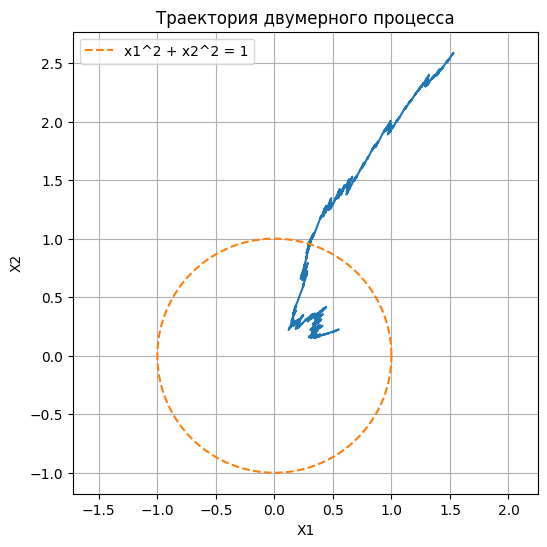

In [11]:
np.random.seed(42)

T = 2.0
dt = 0.001
N = int(T / dt)

X = np.zeros((N + 1, 2))
X[0] = [0.5, 0.2]   # начальная точка

for i in range(N):
    x1, x2 = X[i]

    # drift
    if x1**2 + x2**2 > 1:
        mu = np.array([1.0, 1.0])
    else:
        mu = np.array([-x1, x2])

    # diffusion matrix
    coef = 1 / (1 + x1**2 + x2**2)
    sigma = coef * np.array([[x1, 0],
                             [x2, 0]])

    # случайный шаг
    dW = np.array([np.sqrt(dt) * np.random.randn(), 0.0])

    # схема Эйлера
    X[i + 1] = X[i] + mu * dt + sigma @ dW

# график траектории
plt.figure(figsize=(6, 6))
plt.plot(X[:, 0], X[:, 1])
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Траектория двумерного процесса')
plt.grid()

# единичная окружность
phi = np.linspace(0, 2 * np.pi, 200)
plt.plot(np.cos(phi), np.sin(phi), '--', label='x1^2 + x2^2 = 1')
plt.legend()

plt.axis('equal')
plt.show()